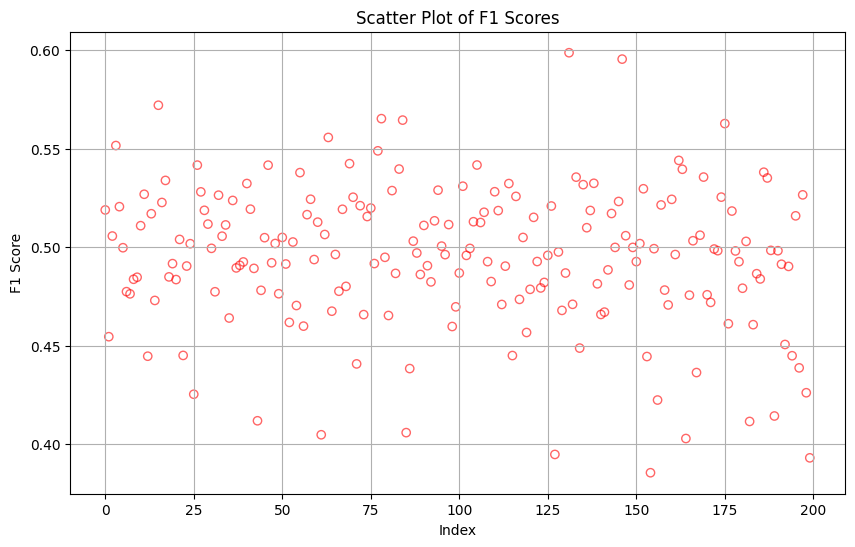

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = './EncodedChromosomes_v5_results.csv'
# Load the data
df = pd.read_csv(CSV_PATH)

# Extract F1 scores
f1_scores = df['F1']

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(f1_scores)), f1_scores, alpha=0.6, edgecolor='r', facecolor='none')
plt.title('Scatter Plot of F1 Scores')
plt.xlabel('Index')
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()


Varianza explicada acumulada con 12 componentes: 99.92%
XGBoost con PCA - MAE: 0.0301, MSE: 0.0015, R2: -0.3882


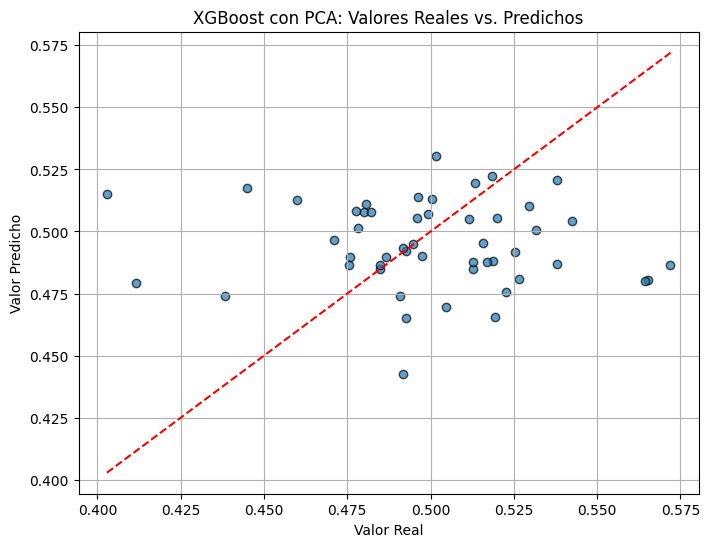

Directorio './surrogates_v5.1' creado.
Modelo XGBoost y PCA guardados en la carpeta './surrogates_v5.1'.
Mejores hiperparámetros encontrados: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 50}
XGBoost (GridSearch) con PCA - MAE: 0.0255, MSE: 0.0011, R2: -0.0356


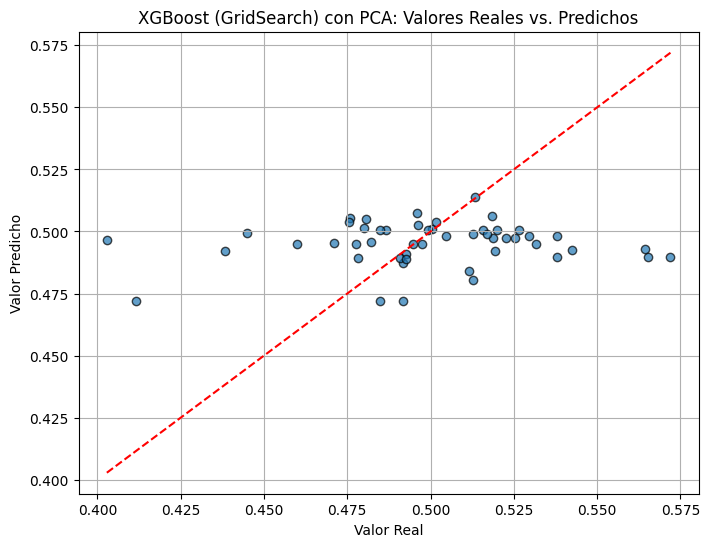

Mejor modelo XGBoost (GridSearch) guardado.
SVR - MAE: 0.0249, MSE: 0.0011, R2: -0.0258


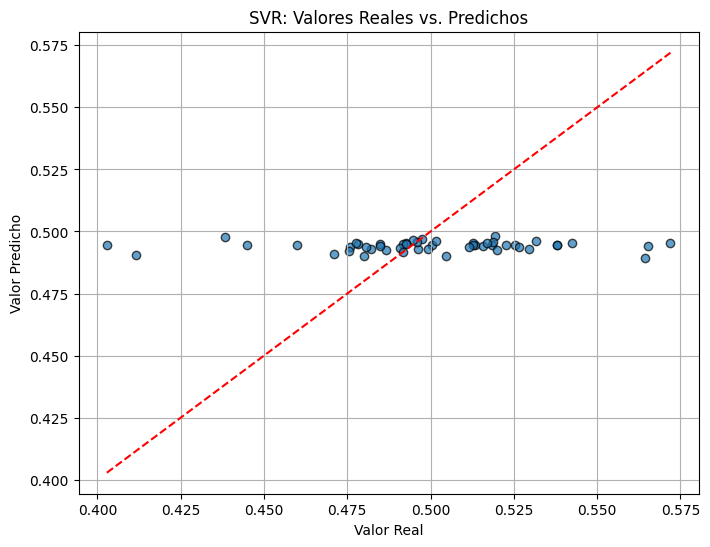

Modelo SVR guardado.
                 Generalized Linear Model Regression Results                  
Dep. Variable:                     F1   No. Observations:                  150
Model:                            GLM   Df Residuals:                      137
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67.907
Date:                Wed, 09 Apr 2025   Deviance:                      0.78925
Time:                        17:41:11   Pearson chi2:                    0.787
No. Iterations:                     3   Pseudo R-squ. (CS):          0.0001839
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0254      0.16

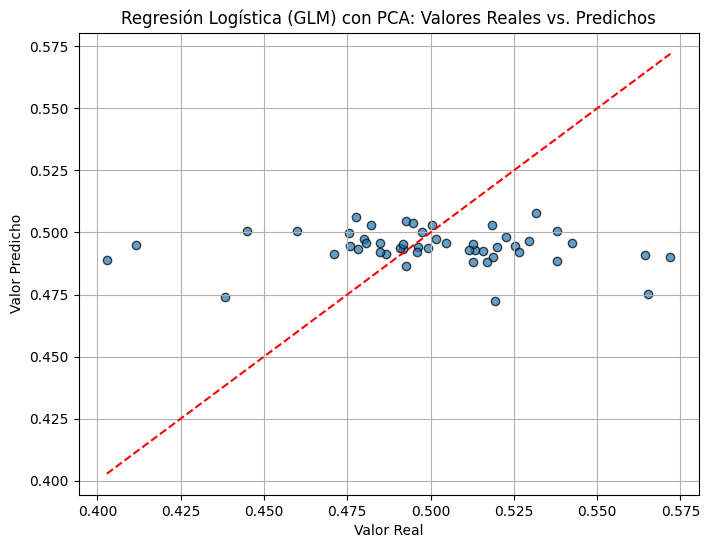

Modelo GLM guardado en: ./surrogates_v5.1\glm_model.pkl


In [2]:
import pandas as pd
import numpy as np
import ast
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.decomposition import PCA
import joblib

# ------------------------------
# Cargar y Preprocesar el Dataset
# ------------------------------
# Se asume que 'df' ya está cargado en el notebook
# Convertir la columna 'Encoded Architecture' de string a lista de enteros
df['Encoded Architecture'] = df['Encoded Architecture'].apply(ast.literal_eval)

# Expandir la lista en 'Encoded Architecture' a 48 columnas
num_features = len(df['Encoded Architecture'].iloc[0])
arch_cols = [f'arch_{i}' for i in range(num_features)]
encoded_arch_df = pd.DataFrame(df['Encoded Architecture'].tolist(), columns=arch_cols)

# Definir la variable objetivo para regresión (F1 score, valores entre 0 y 1)
y_reg = df['F1']

# ------------------------------
# Aplicar PCA para reducir a 12 componentes
# ------------------------------
pca = PCA(n_components=12, random_state=42)
X_pca = pca.fit_transform(encoded_arch_df)

# Imprimir la varianza explicada acumulada
print("Varianza explicada acumulada con 12 componentes: {:.2%}".format(np.sum(pca.explained_variance_ratio_)))

# Dividir los datos para regresión
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_reg, test_size=0.25, random_state=42)

# ------------------------------
# Función para graficar Predicted vs Ground Truth (Regresión)
# ------------------------------
def plot_scatter(y_true, y_pred, title):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.title(title)
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Predicho')
    plt.grid(True)
    plt.show()

# ------------------------------
# Modelo Base: XGBoost con PCA
# ------------------------------
model_xgb = xgb.XGBRegressor(random_state=42)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

# Evaluar el modelo base XGBoost
mae = mean_absolute_error(y_test, pred_xgb)
mse = mean_squared_error(y_test, pred_xgb)
r2 = r2_score(y_test, pred_xgb)
print("XGBoost con PCA - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae, mse, r2))

# Gráfica Predicted vs Ground Truth para el modelo base
plot_scatter(y_test, pred_xgb, 'XGBoost con PCA: Valores Reales vs. Predichos')

# ------------------------------
# Guardar el modelo base y el PCA
# ------------------------------
SAVE_PATH = "./surrogates_v5.1"
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)
    print(f"Directorio '{SAVE_PATH}' creado.")

joblib.dump(model_xgb, os.path.join(SAVE_PATH, 'xgboost_model_pca.pkl'))
joblib.dump(pca, os.path.join(SAVE_PATH, 'pca_transformer.pkl'))
print(f"Modelo XGBoost y PCA guardados en la carpeta '{SAVE_PATH}'.")

# ------------------------------
# Grid Search para ajustar hiperparámetros (XGBoost)
# ------------------------------
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(estimator=xgb.XGBRegressor(random_state=42),
                           param_grid=param_grid,
                           scoring='neg_mean_absolute_error',
                           cv=5,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)

# Evaluar el mejor modelo obtenido con GridSearch
best_model = grid_search.best_estimator_
pred_best = best_model.predict(X_test)
mae_best = mean_absolute_error(y_test, pred_best)
mse_best = mean_squared_error(y_test, pred_best)
r2_best = r2_score(y_test, pred_best)
print("XGBoost (GridSearch) con PCA - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae_best, mse_best, r2_best))

# Gráfica Predicted vs Ground Truth para el mejor modelo
plot_scatter(y_test, pred_best, 'XGBoost (GridSearch) con PCA: Valores Reales vs. Predichos')

# Guardar el mejor modelo de GridSearch
joblib.dump(best_model, os.path.join(SAVE_PATH, 'xgboost_best_model_pca.pkl'))
print("Mejor modelo XGBoost (GridSearch) guardado.")

# ------------------------------
# Implementar Support Vector Regression (SVR)
# ------------------------------
from sklearn.svm import SVR

model_svr = SVR(kernel='rbf')
model_svr.fit(X_train, y_train)
pred_svr = model_svr.predict(X_test)

mae_svr = mean_absolute_error(y_test, pred_svr)
mse_svr = mean_squared_error(y_test, pred_svr)
r2_svr = r2_score(y_test, pred_svr)
print("SVR - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae_svr, mse_svr, r2_svr))

# Gráfica para SVR
plot_scatter(y_test, pred_svr, 'SVR: Valores Reales vs. Predichos')

# Guardar el modelo SVR
joblib.dump(model_svr, os.path.join(SAVE_PATH, 'svr_model.pkl'))
print("Modelo SVR guardado.")

# ------------------------------
# Implementar Regresión Logística (GLM) para regresión de proporciones
# ------------------------------
import statsmodels.api as sm

# Usamos el mismo X_pca y y_reg (sin discretización) para el GLM
X_train_glm, X_test_glm, y_train_glm, y_test_glm = train_test_split(X_pca, y_reg, test_size=0.25, random_state=42)

# Agregar constante (requisito para statsmodels)
X_train_glm_const = sm.add_constant(X_train_glm)
X_test_glm_const = sm.add_constant(X_test_glm)

# Ajustar GLM con familia Binomial y enlace logit
glm_binom = sm.GLM(y_train_glm, X_train_glm_const, family=sm.families.Binomial())
result_glm = glm_binom.fit()
print(result_glm.summary())

# Realizar predicciones (los valores estarán entre 0 y 1)
pred_glm = result_glm.predict(X_test_glm_const)

mae_glm = mean_absolute_error(y_test_glm, pred_glm)
mse_glm = mean_squared_error(y_test_glm, pred_glm)
r2_glm = r2_score(y_test_glm, pred_glm)
print("Regresión Logística (GLM) - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae_glm, mse_glm, r2_glm))
plot_scatter(y_test_glm, pred_glm, 'Regresión Logística (GLM) con PCA: Valores Reales vs. Predichos')

# Guardar el modelo GLM utilizando el método propio de statsmodels
glm_save_path = os.path.join(SAVE_PATH, 'glm_model.pkl')
result_glm.save(glm_save_path)
print("Modelo GLM guardado en:", glm_save_path)


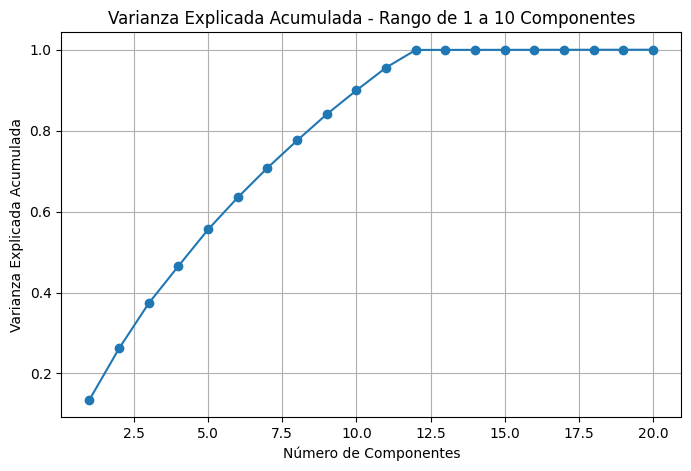

1 componentes: 13.52% de varianza explicada acumulada
2 componentes: 26.20% de varianza explicada acumulada
3 componentes: 37.36% de varianza explicada acumulada
4 componentes: 46.54% de varianza explicada acumulada
5 componentes: 55.57% de varianza explicada acumulada
6 componentes: 63.48% de varianza explicada acumulada
7 componentes: 70.79% de varianza explicada acumulada
8 componentes: 77.55% de varianza explicada acumulada
9 componentes: 84.05% de varianza explicada acumulada
10 componentes: 89.94% de varianza explicada acumulada
11 componentes: 95.57% de varianza explicada acumulada
12 componentes: 99.93% de varianza explicada acumulada
13 componentes: 99.94% de varianza explicada acumulada
14 componentes: 99.94% de varianza explicada acumulada
15 componentes: 99.95% de varianza explicada acumulada
16 componentes: 99.96% de varianza explicada acumulada
17 componentes: 99.96% de varianza explicada acumulada
18 componentes: 99.97% de varianza explicada acumulada
19 componentes: 99.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = encoded_arch_df.values

max_components = 20
cumulative_variances = []

for n in range(1, max_components + 1):
    pca = PCA(n_components=n, random_state=42)
    pca.fit(X)
    cum_var = np.sum(pca.explained_variance_ratio_)
    cumulative_variances.append(cum_var)

plt.figure(figsize=(8,5))
plt.plot(range(1, max_components + 1), cumulative_variances, marker='o')
plt.title('Varianza Explicada Acumulada - Rango de 1 a 10 Componentes')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()

# Imprimir valores en pantalla
for i, cv in enumerate(cumulative_variances, start=1):
    print(f"{i} componentes: {cv:.2%} de varianza explicada acumulada")


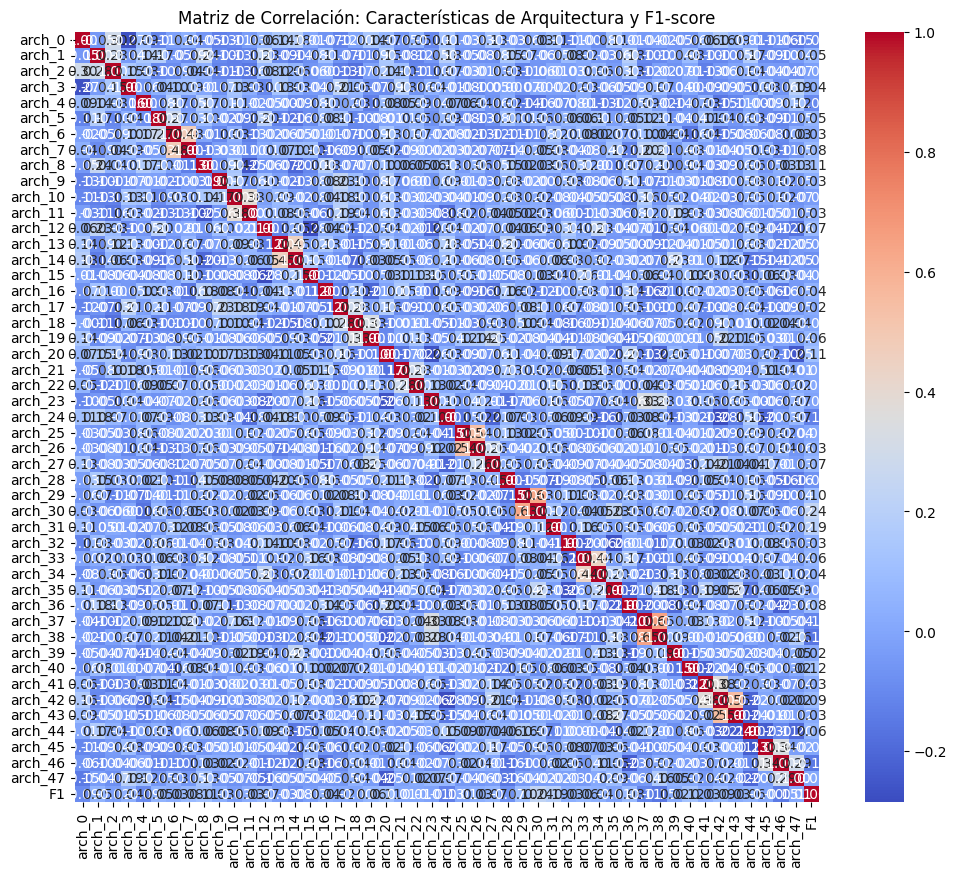

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Concatenar las 48 columnas de arquitectura con el F1-score para el análisis
df_corr = pd.concat([encoded_arch_df, df['F1']], axis=1)

# Calcular la matriz de correlación
corr_matrix = df_corr.corr()

# Graficar la matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matriz de Correlación: Características de Arquitectura y F1-score")
plt.show()


Epoch 1/1000


c:\Users\herna\anaconda3\envs\pytorch\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.5620 - mae: 0.5992 - val_loss: 0.2959 - val_mae: 0.4537
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3451 - mae: 0.4428 - val_loss: 0.1862 - val_mae: 0.3447
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2783 - mae: 0.3948 - val_loss: 0.1470 - val_mae: 0.2964
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2166 - mae: 0.3340 - val_loss: 0.1283 - val_mae: 0.2786
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1977 - mae: 0.3393 - val_loss: 0.1190 - val_mae: 0.2716
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1437 - mae: 0.3030 - val_loss: 0.1160 - val_mae: 0.2726
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1106 - mae: 0.2720 - val_loss: 0.1111 - val_mae: 0.2681
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0896 - mae: 0.2344 - val_loss: 0.1013 - val_mae: 0.2525
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0973 - mae: 0.24

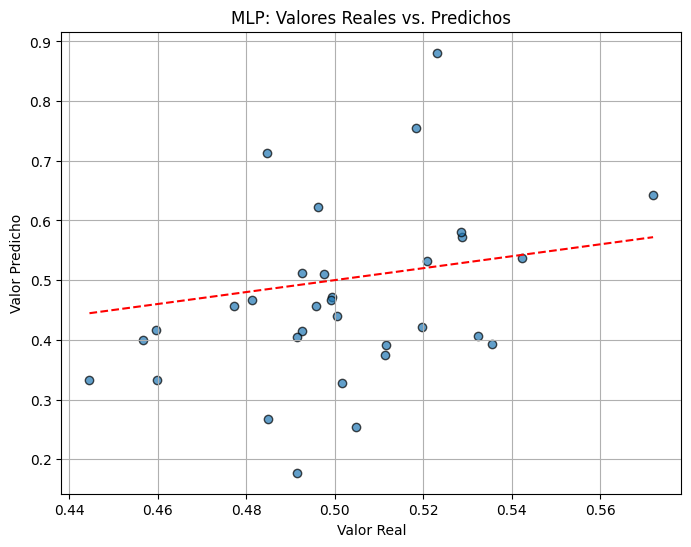

Epoch 1/1000


c:\Users\herna\anaconda3\envs\pytorch\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.1500 - mae: 0.3460 - val_loss: 0.0397 - val_mae: 0.1574
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0317 - mae: 0.1400 - val_loss: 0.0299 - val_mae: 0.1572
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0222 - mae: 0.1339 - val_loss: 0.0128 - val_mae: 0.0984
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0087 - mae: 0.0752 - val_loss: 0.0121 - val_mae: 0.0851
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0101 - mae: 0.0816 - val_loss: 0.0106 - val_mae: 0.0898
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0066 - mae: 0.0669 - val_loss: 0.0095 - val_mae: 0.0837
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0043 - mae: 0.0531 - val_loss: 0.0068 - val_mae: 0.0657
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0052 - mae: 0.0565 - val_loss: 0.0060 - val_mae: 0.0626
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0036 - mae: 0.04

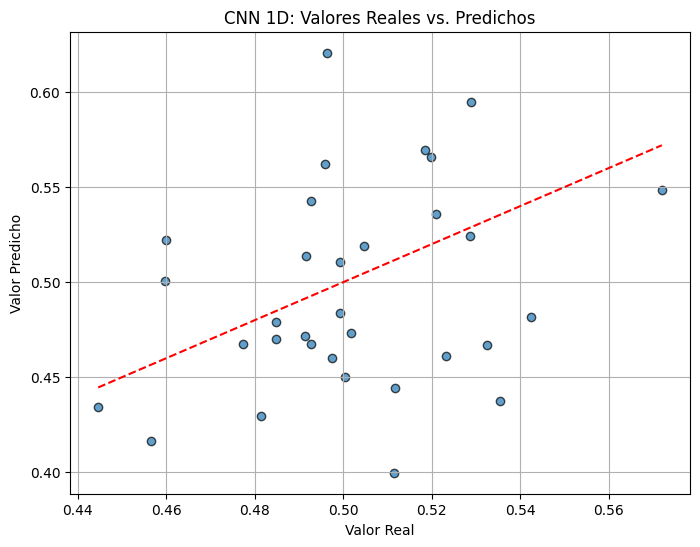

In [5]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ----------------------------------------------------------------
# Cargar y Preprocesar el Dataset (Variable: data_df)
# ----------------------------------------------------------------
data_df = pd.read_csv(CSV_PATH)  # Asegúrate de tener el archivo en el directorio actual

# Convertir la columna 'Encoded Architecture' de string a lista de enteros
data_df['Encoded Architecture'] = data_df['Encoded Architecture'].apply(ast.literal_eval)

# Expandir la lista en 'Encoded Architecture' a múltiples columnas
num_features = len(data_df['Encoded Architecture'].iloc[0])
arch_cols = [f'arch_{i}' for i in range(num_features)]
arch_df = pd.DataFrame(data_df['Encoded Architecture'].tolist(), columns=arch_cols)

# Concatenar las nuevas columnas y eliminar la columna original
data_df = pd.concat([arch_df, data_df.drop(columns=['Encoded Architecture'])], axis=1)

# Definir las variables: X (features) y y (variable objetivo: F1-score)
X = data_df.drop(columns=['F1'])
y = data_df['F1']

# ----------------------------------------------------------------
# Normalizar las características
# ----------------------------------------------------------------
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# ----------------------------------------------------------------
# Dividir en conjuntos de entrenamiento y prueba
# ----------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ----------------------------------------------------------------
# Función para graficar la dispersión: Valores Reales vs. Predichos
# ----------------------------------------------------------------
def plot_scatter(y_true, y_pred, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.title(title)
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Predicho')
    plt.grid(True)
    plt.show()

# ----------------------------------------------------------------
# Configurar Early Stopping para evitar sobreentrenamiento
# ----------------------------------------------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ----------------------------------------------------------------
# MODELO 1: MLP (Red Neuronal Multicapa)
# ----------------------------------------------------------------
model_mlp = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Capa de salida para regresión
])

model_mlp.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])

# Entrenar el modelo MLP
history_mlp = model_mlp.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=1000,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

# Realizar predicciones y evaluar el modelo MLP
pred_mlp = model_mlp.predict(X_test).flatten()
mae_mlp = mean_absolute_error(y_test, pred_mlp)
mse_mlp = mean_squared_error(y_test, pred_mlp)
r2_mlp = r2_score(y_test, pred_mlp)
print("MLP - MAE:", mae_mlp, "MSE:", mse_mlp, "R2:", r2_mlp)

# Graficar la dispersión para el modelo MLP
plot_scatter(y_test, pred_mlp, 'MLP: Valores Reales vs. Predichos')

# ----------------------------------------------------------------
# MODELO 2: CNN 1D
# ----------------------------------------------------------------
# Remodelar los datos para que tengan 3 dimensiones: (n_samples, n_features, 1)
X_train_cnn = X_train.reshape(-1, X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(-1, X_test.shape[1], 1)

model_cnn = Sequential([
    Conv1D(256, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model_cnn.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])

# Entrenar el modelo CNN
history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=1000,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

# Realizar predicciones y evaluar el modelo CNN
pred_cnn = model_cnn.predict(X_test_cnn).flatten()
mae_cnn = mean_absolute_error(y_test, pred_cnn)
mse_cnn = mean_squared_error(y_test, pred_cnn)
r2_cnn = r2_score(y_test, pred_cnn)
print("CNN - MAE:", mae_cnn, "MSE:", mse_cnn, "R2:", r2_cnn)

# Graficar la dispersión para el modelo CNN
plot_scatter(y_test, pred_cnn, 'CNN 1D: Valores Reales vs. Predichos')
